#Training for 31 conditions

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Comb_ligands_31conditions_y_codon_202604.csv to Comb_ligands_31conditions_y_codon_202604.csv
Saving Comb_ligands_31conditions_X_codon_202604.csv to Comb_ligands_31conditions_X_codon_202604.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load the data
X = pd.read_csv('Comb_ligands_31conditions_X_codon_202604.csv', header=None)
y = pd.read_csv('Comb_ligands_31conditions_y_codon_202604.csv', header=None)

print("X shape:", X.shape)
print("y shape:", y.shape)

#X = X.iloc[0::9, :]
#y = y.iloc[0::9, :]

#print(X.shape)
#print(y.shape)

# Define the label mapping
label_mapping = {
    0: 'TNF', 1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK',
    5: 'TNF_LPS', 6: 'TNF_CpG', 7: 'TNF_PolyIC', 8: 'TNF_Pam3CSK',
    9: 'LPS_CpG', 10: 'LPS_PolyIC', 11: 'LPS_Pam3CSK', 12: 'CpG_PolyIC',
    13: 'CpG_Pam3CSK', 14: 'PolyIC_Pam3CSK', 15: 'TNF_LPS_CpG',
    16: 'TNF_LPS_PolyIC', 17: 'TNF_LPS_Pam3CSK', 18: 'TNF_CpG_PolyIC',
    19: 'TNF_CpG_Pam3CSK', 20: 'TNF_PolyIC_Pam3CSK', 21: 'LPS_CpG_PolyIC',
    22: 'LPS_CpG_Pam3CSK', 23: 'LPS_PolyIC_Pam3CSK', 24: 'CpG_PolyIC_Pam3CSK',
    25: 'TNF_LPS_CpG_PolyIC', 26: 'TNF_LPS_CpG_Pam3CSK',
    27: 'TNF_LPS_PolyIC_Pam3CSK', 28: 'TNF_CpG_PolyIC_Pam3CSK',
    29: 'LPS_CpG_PolyIC_Pam3CSK', 30: 'TNF_LPS_CpG_PolyIC_Pam3CSK'
}

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)

# Define and train the model
model = RandomForestClassifier(random_state=1)
model.fit(X_train, y_train.values.ravel())

# Make predictions on the test set
y_pred = model.predict(X_test)

# Create confusion matrix using only test set predictions
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"Sum of confusion matrix: {np.sum(cm)}") # Verify the size of the confusion matrix

unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Condition {label}: {count} samples")

print(f"Total: {sum(counts)} (should be 30,990)")

# Calculate accuracy
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.3f}")

# Sensitivity Calculation (using the test set confusion matrix)
TP = np.diag(cm)  # True Positives
FN = np.sum(cm, axis=1) - TP  # False Negatives

# Compute sensitivity for the full confusion matrix
recall = cm / np.sum(cm, axis=1, keepdims=True)  # Normalize by row sums
recall = np.nan_to_num(recall)  # Replace NaN with 0 (for rows with zero actual instances)
print(recall)
print(np.sum(recall, axis=1))

# Precision Calculation (using the test set confusion matrix)
TP = np.diag(cm)  # True Positives
FP = np.sum(cm, axis=0) - TP  # False Positives

# Compute precision for the full confusion matrix
precision = cm / np.sum(cm, axis=0, keepdims=True)  # Normalize by column sums
precision = np.nan_to_num(precision)  # Replace NaN with 0 (for columns with zero predictions)
print(precision)
print(np.sum(precision, axis=0))

# Compute f-1 score for the full confusion matrix
# Ensure denominator is never zero by adding a small epsilon
epsilon = 1e-10  # A tiny constant to avoid division by zero
f1_score = np.where(
    (precision + recall) == 0,
    0,  # Assign 0 when both precision and recall are zero
    2 * (precision * recall) / (precision + recall + epsilon)  # Avoid exact zero division
)
print(f1_score)
print(np.sum(f1_score, axis=0))


X shape: (30990, 6)
y shape: (30990, 1)
[[300   0   0   0   1   2   4   6   5   0   2   0   0   0   3   0   2   0
    2   0   1   1   0   0   0   1   0   0   0   0   0]
 [  1 153  10   6  19   8   8   3   1  16   9   9  12  12  10   5   2   1
    3   1   1   5   9   6   8   3   2   0   1   6   0]
 [  0  18 160  16  12   7  10   5   5  15   3   2  21  13   9   5   2   2
    1   2   3   2   5   1   3   1   1   1   0   4   1]
 [  1   1   7 249   2   0   0   3   0   0   3   0  59   2   0   0   1   0
    0   0   0   1   0   0   1   0   0   0   0   0   0]
 [  9   9   9   6 162   3   2   3   3   6   4   2  15  16  37   1   2   0
    3   2   3   7   1   2  19   0   0   0   0   4   0]
 [  5  27   6   2   4 129  10  10   8   1   5   2  13   4   4  14  12  10
    8   3   3   5   1   3   5   6   7   6   6   2   9]
 [ 19   3  14   3   6   7 130   9   8   9   2   3   6   5   4  20  11   7
    7   9   6   4   6   0   1  11   3   1   7   2   7]
 [ 18   1   3   6   6   7  10 141   6   2   2   0   5   4

In [3]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)

numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1


#Fig 3c barplots

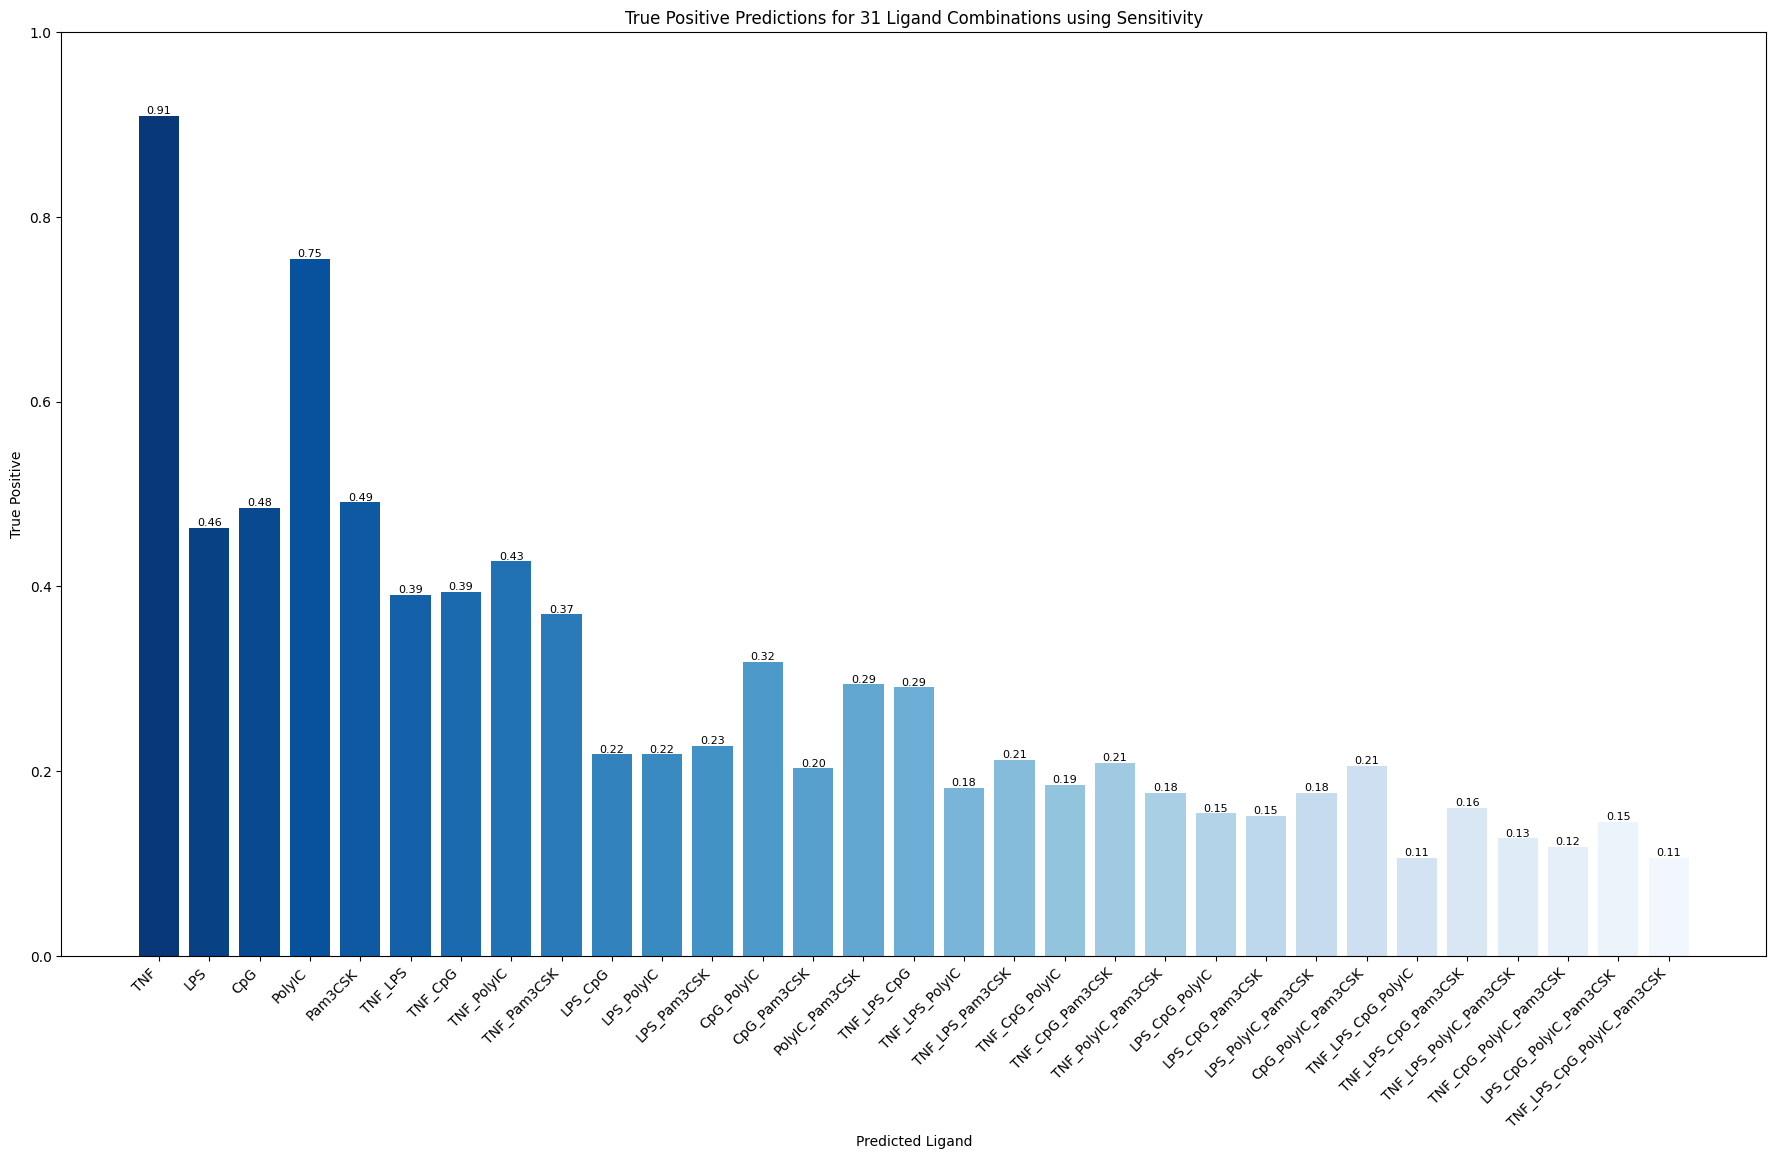

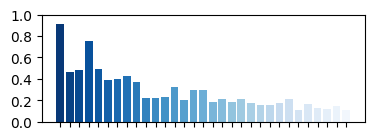

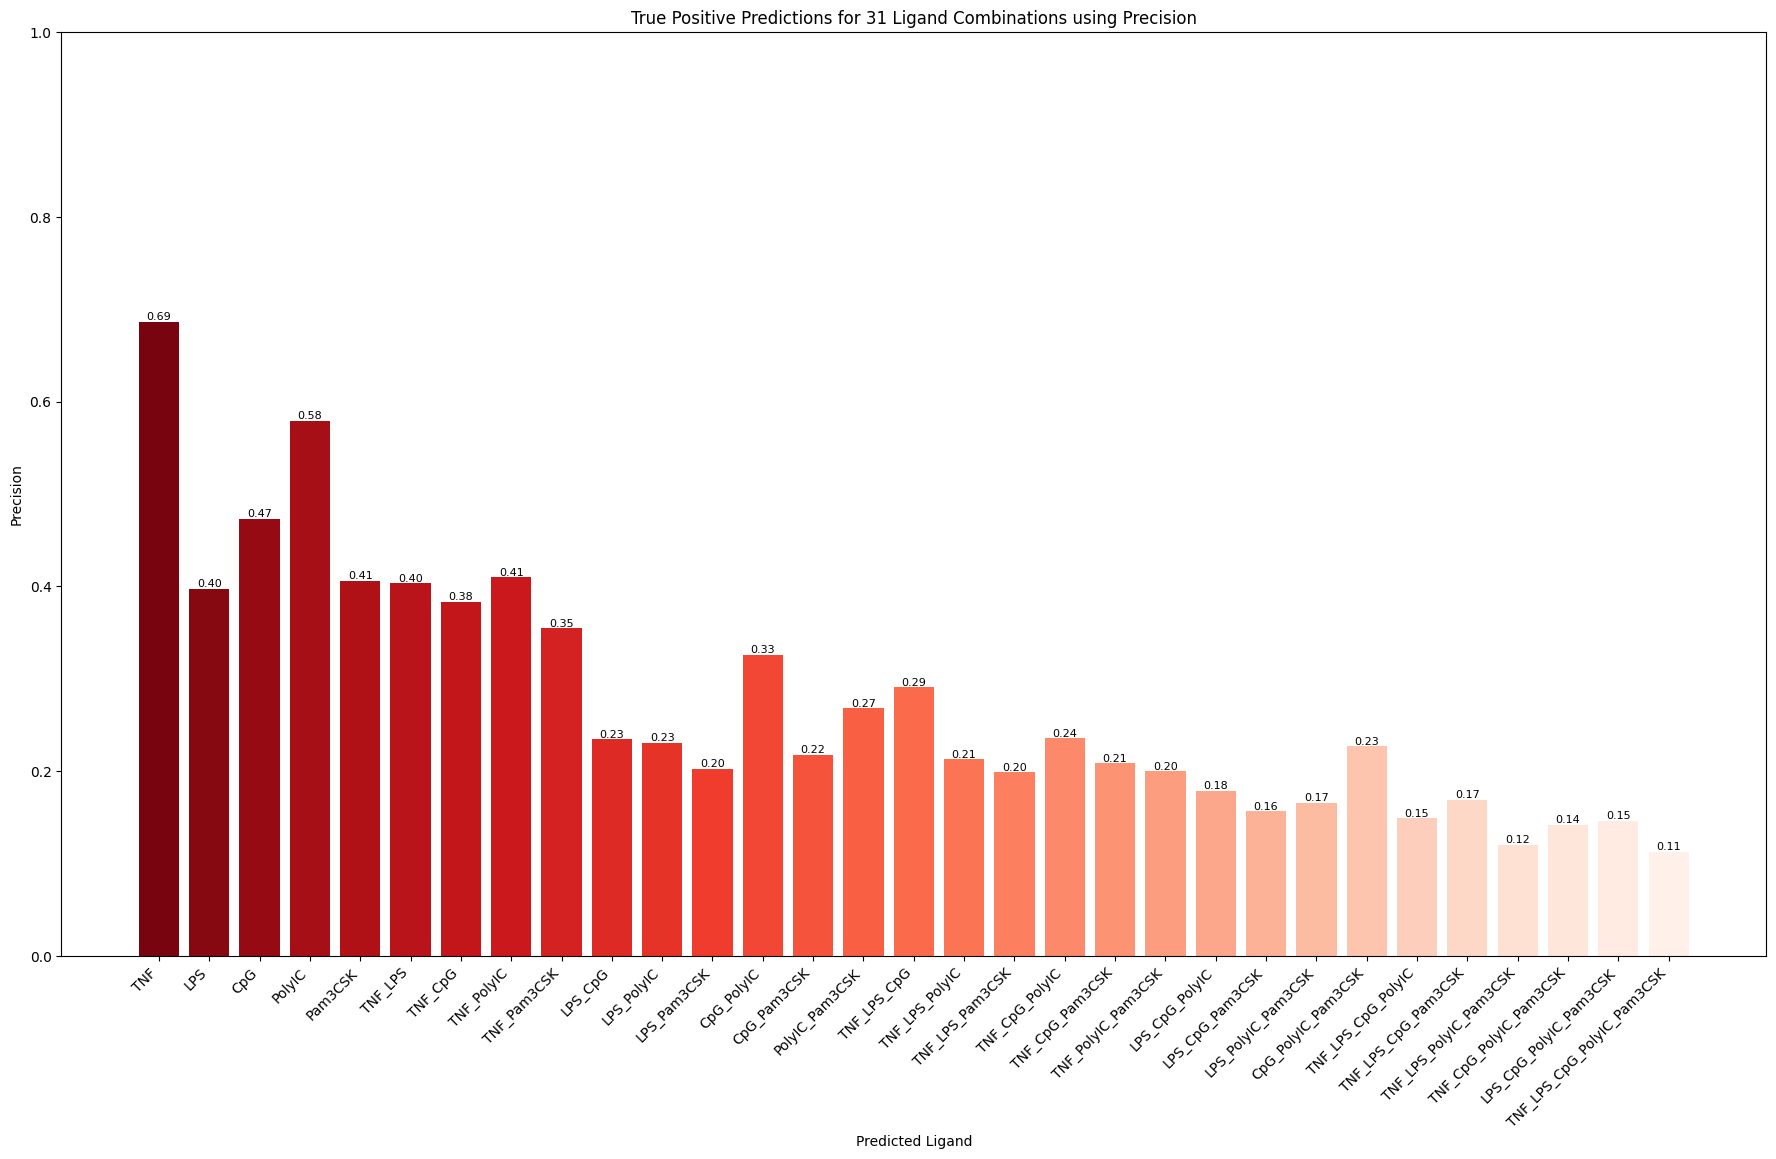

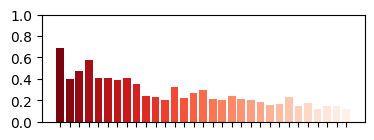

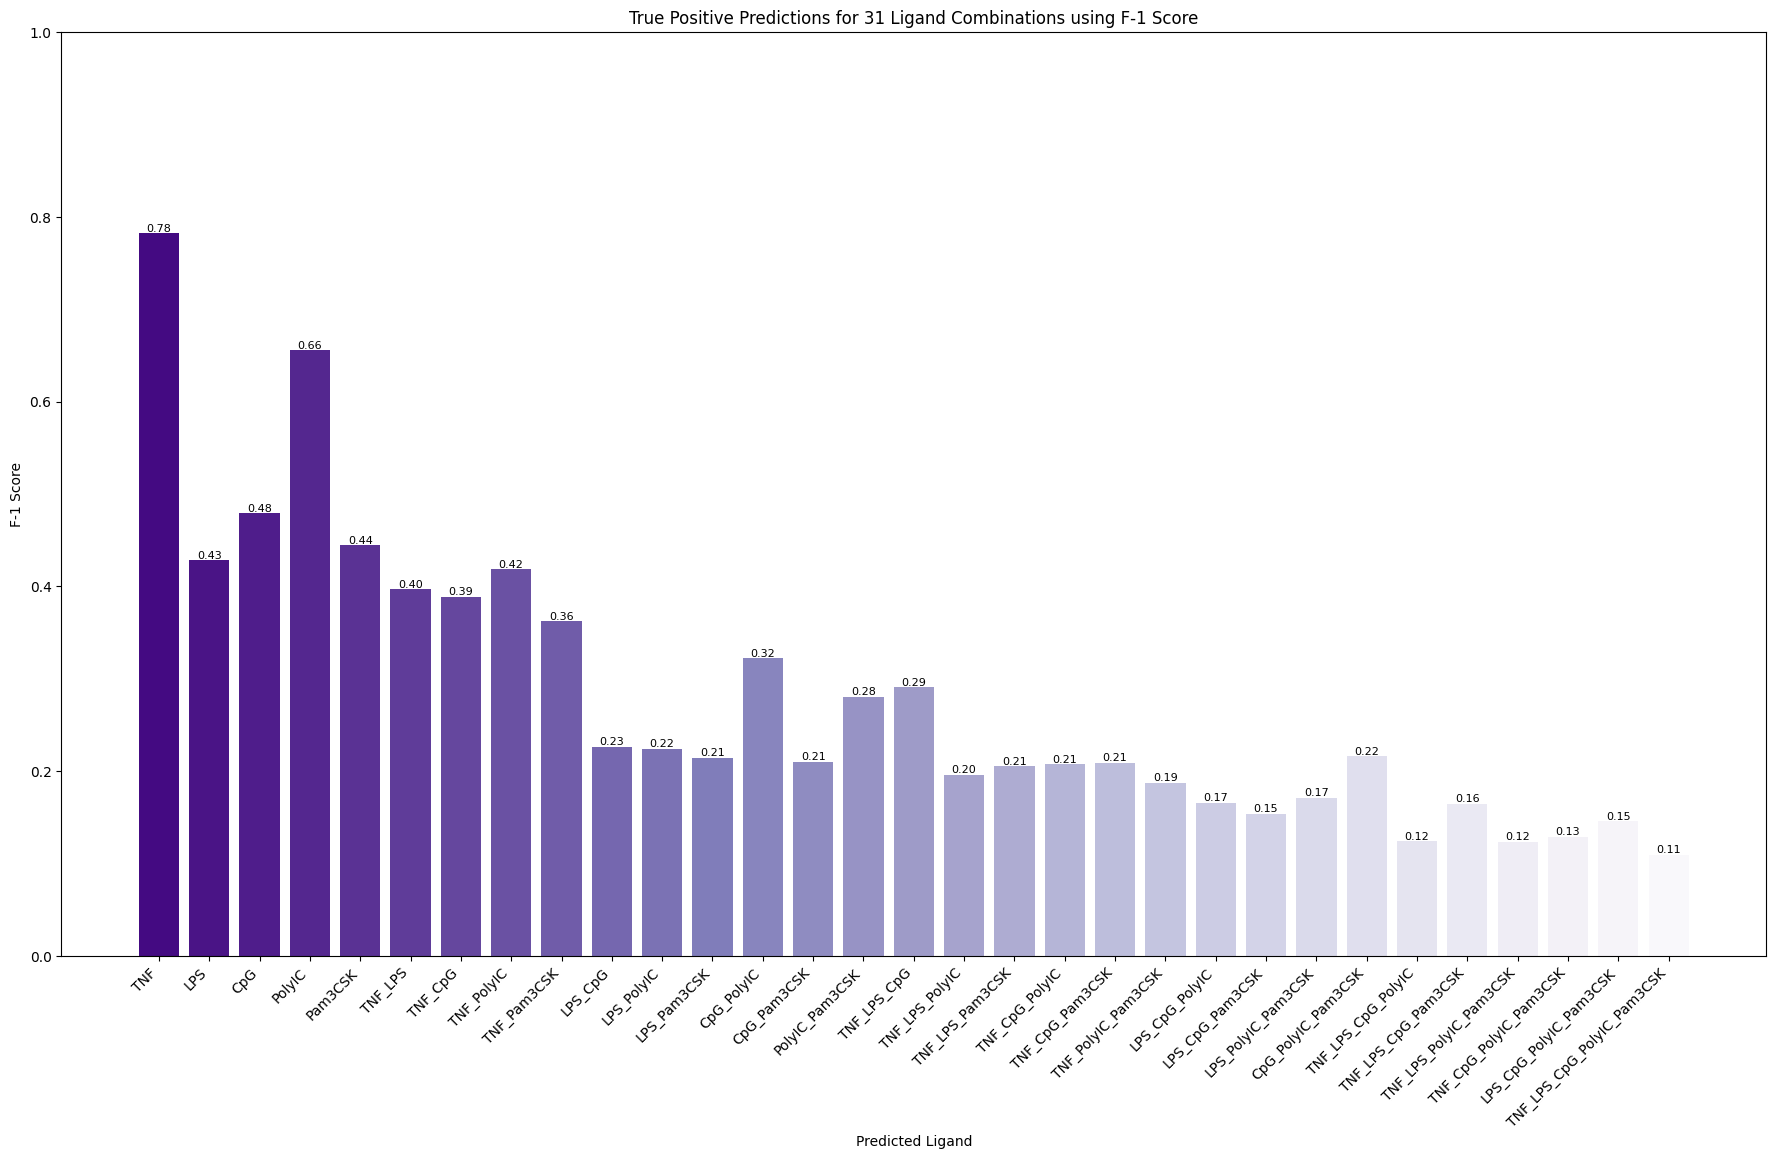

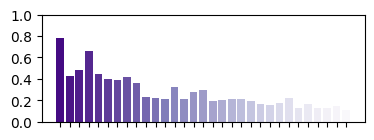

In [4]:
# Extract only the diagonal values
precision_diag = np.diag(precision)  # True positive precision values
recall_diag = np.diag(recall)  # True positive recall values
f1_score_diag = 2 * (precision_diag * recall_diag) / (precision_diag + recall_diag)

  # True positive f1 score values
f1_score_diagonal = np.full_like(f1_score, np.nan)  # Create NaN matrix for visualization
np.fill_diagonal(f1_score_diagonal, f1_score_diag)  # Fill diagonal with F1-scores

# Set to 1 to automatically download PNGs, 0 to not download
auto_download = 0
def save_and_download(filename, download=False, formats=None):
    """Saves the current figure in specified formats and optionally downloads it."""
    if formats is None:
        formats = ['pdf']  # Default format if none specified

    for fmt in formats:
        plt.savefig(f"{filename}.{fmt}", bbox_inches='tight', dpi=300)
        if download and auto_download:
            try:
                from google.colab import files
                files.download(f"{filename}.{fmt}")
            except ImportError:
                print("Not running in Colab environment.  Download skipped.")

# Recall Bar Plot
def plot_recall(with_labels=True):
    if with_labels:
        plt.figure(figsize=(22, 12))
        num_classes = len(recall_diag)
        colors = sns.color_palette("Blues_r", n_colors=num_classes)

        bars = plt.bar(range(num_classes), recall_diag, color=colors)

        plt.title("True Positive Predictions for 31 Ligand Combinations using Sensitivity")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("True Positive")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_mapping[i] for i in range(num_classes)], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        #save_and_download("31conditions_recall_bar_plot_with_labels", download=True, formats=['pdf'])
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts
        plt.bar(range(len(recall_diag)), recall_diag, color=sns.color_palette("Blues_r", n_colors=len(recall_diag)))
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len(recall_diag)))  # Set tick locations
        plt.gca().set_xticklabels([])  # Remove tick labels
        #save_and_download("31conditions_recall_bar_plot_without_labels", download=True, formats=['pdf', 'png', 'eps', 'svg'])

    plt.show()

# Precision Bar Plot
def plot_precision(with_labels=True):
    if with_labels:
        plt.figure(figsize=(22, 12))
        num_classes = len(precision_diag)
        colors = sns.color_palette("Reds_r", n_colors=num_classes)

        bars = plt.bar(range(num_classes), precision_diag, color=colors)

        plt.title("True Positive Predictions for 31 Ligand Combinations using Precision")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Precision")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_mapping[i] for i in range(num_classes)], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        #save_and_download("31conditions_precision_bar_plot_with_labels", download=True, formats=['pdf'])
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts
        plt.bar(range(len(precision_diag)), precision_diag, color=sns.color_palette("Reds_r", n_colors=len(precision_diag)))
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len(precision_diag)))  # Set tick locations
        plt.gca().set_xticklabels([])  # Remove tick labels
        #save_and_download("31conditions_precision_bar_plot_without_labels", download=True, formats=['pdf','png', 'eps', 'svg'])

    plt.show()

# f1_score_diag Bar plot
def plot_f1_score_diag(with_labels=True):
    plt.figure(figsize=(22, 12) if with_labels else (300/72, 100/72))  # Set figure size

    num_classes = len(f1_score_diag)  # Use f1_score_diag for diagonal elements
    colors = sns.color_palette("Purples_r", n_colors=num_classes)

    bars = plt.bar(range(num_classes), f1_score_diag, color=colors)

    plt.ylim(0, 1)
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

    if with_labels:
        plt.title("True Positive Predictions for 31 Ligand Combinations using F-1 Score")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("F-1 Score")
        plt.xticks(range(num_classes), [label_mapping[i] for i in range(num_classes)], rotation=45, ha='right')

        # Annotate bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}',
                     ha='center', va='bottom', fontsize=8)

        # Save labeled plot once (moved outside the loop)
        save_and_download("31conditions_f1score_bar_plot_with_labels", download=True, formats=['pdf'])
    else:
        plt.xticks(range(num_classes))  # Set tick locations
        plt.gca().set_xticklabels([])  # Hide x-axis labels

        # Save unlabeled plot in multiple formats
        save_and_download("31conditions_f1score_bar_plot_without_labels", download=True, formats=['pdf', 'png', 'eps', 'svg'])

    plt.show()



# Generate all versions of the plots
plot_recall(with_labels=True)
plot_recall(with_labels=False)
plot_precision(with_labels=True)
plot_precision(with_labels=False)
plot_f1_score_diag(with_labels=True)
plot_f1_score_diag(with_labels=False)

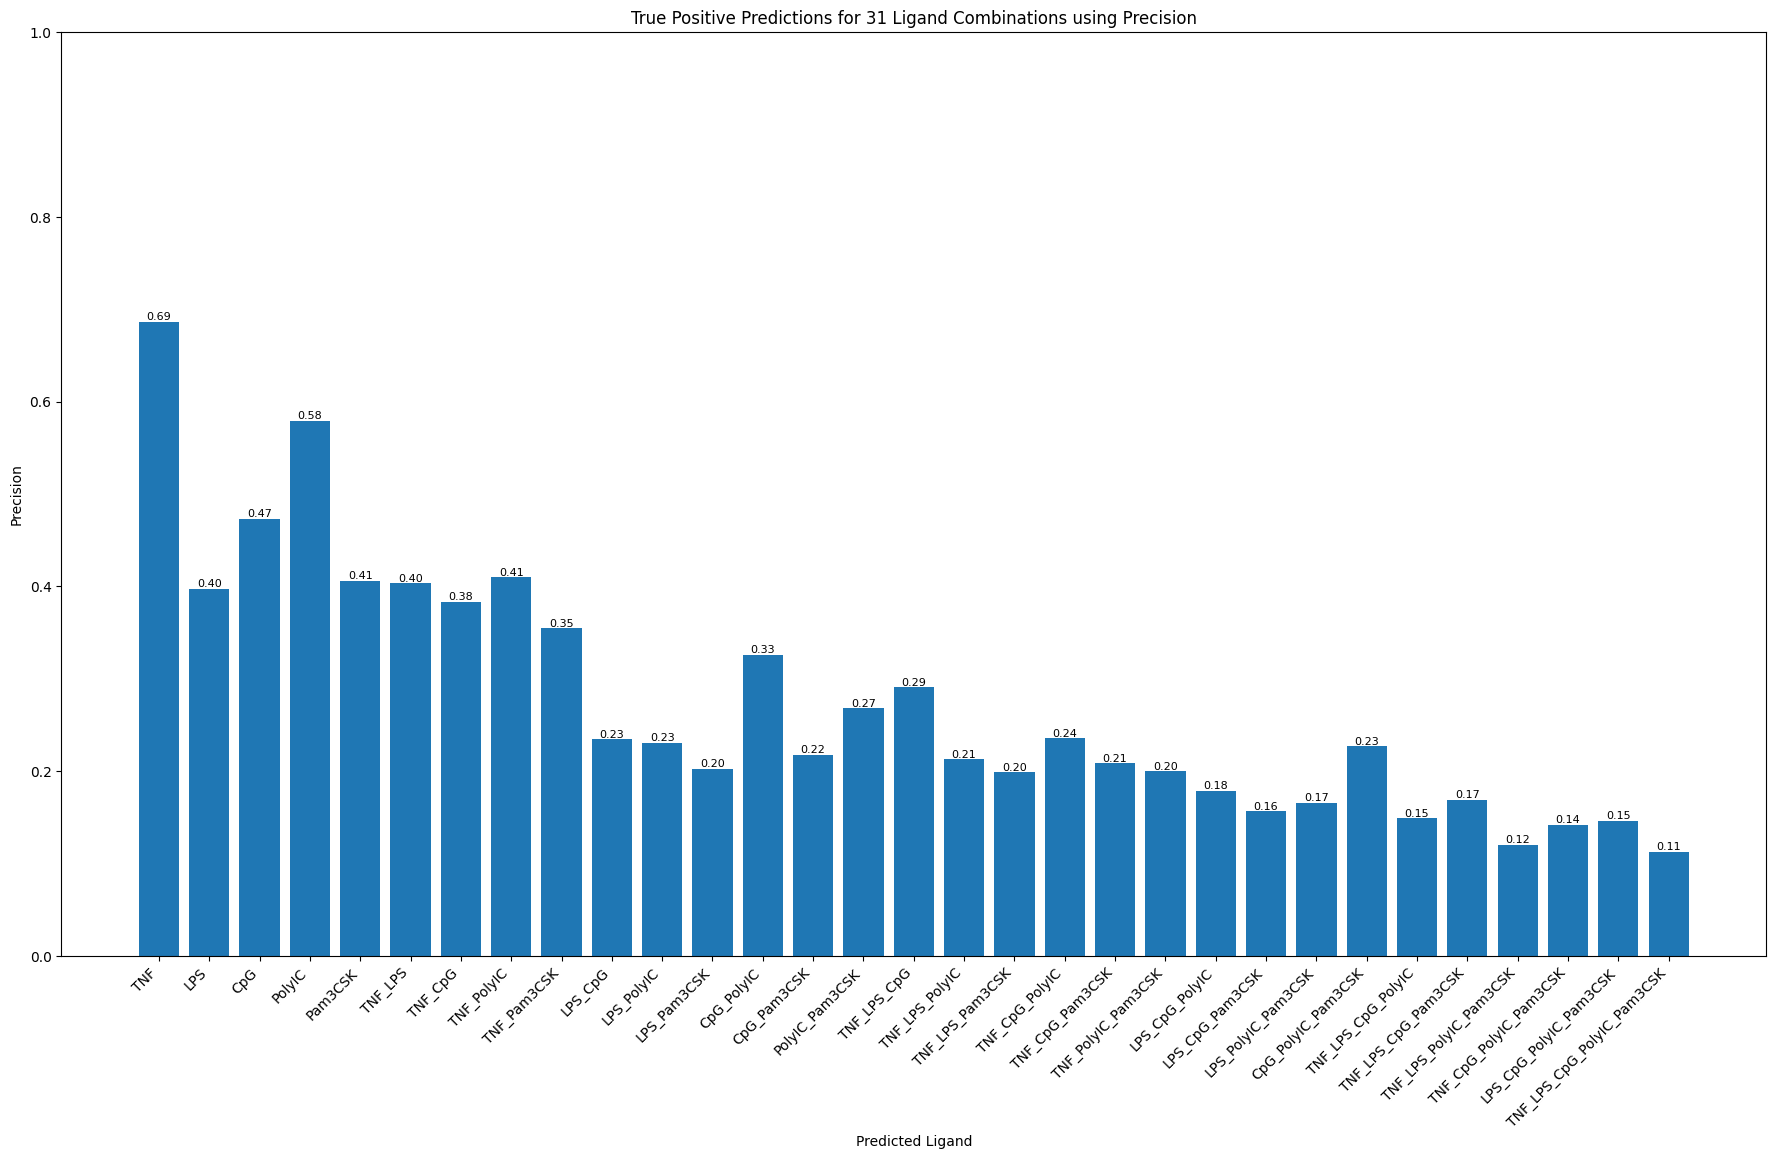

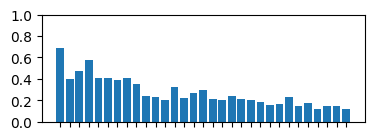

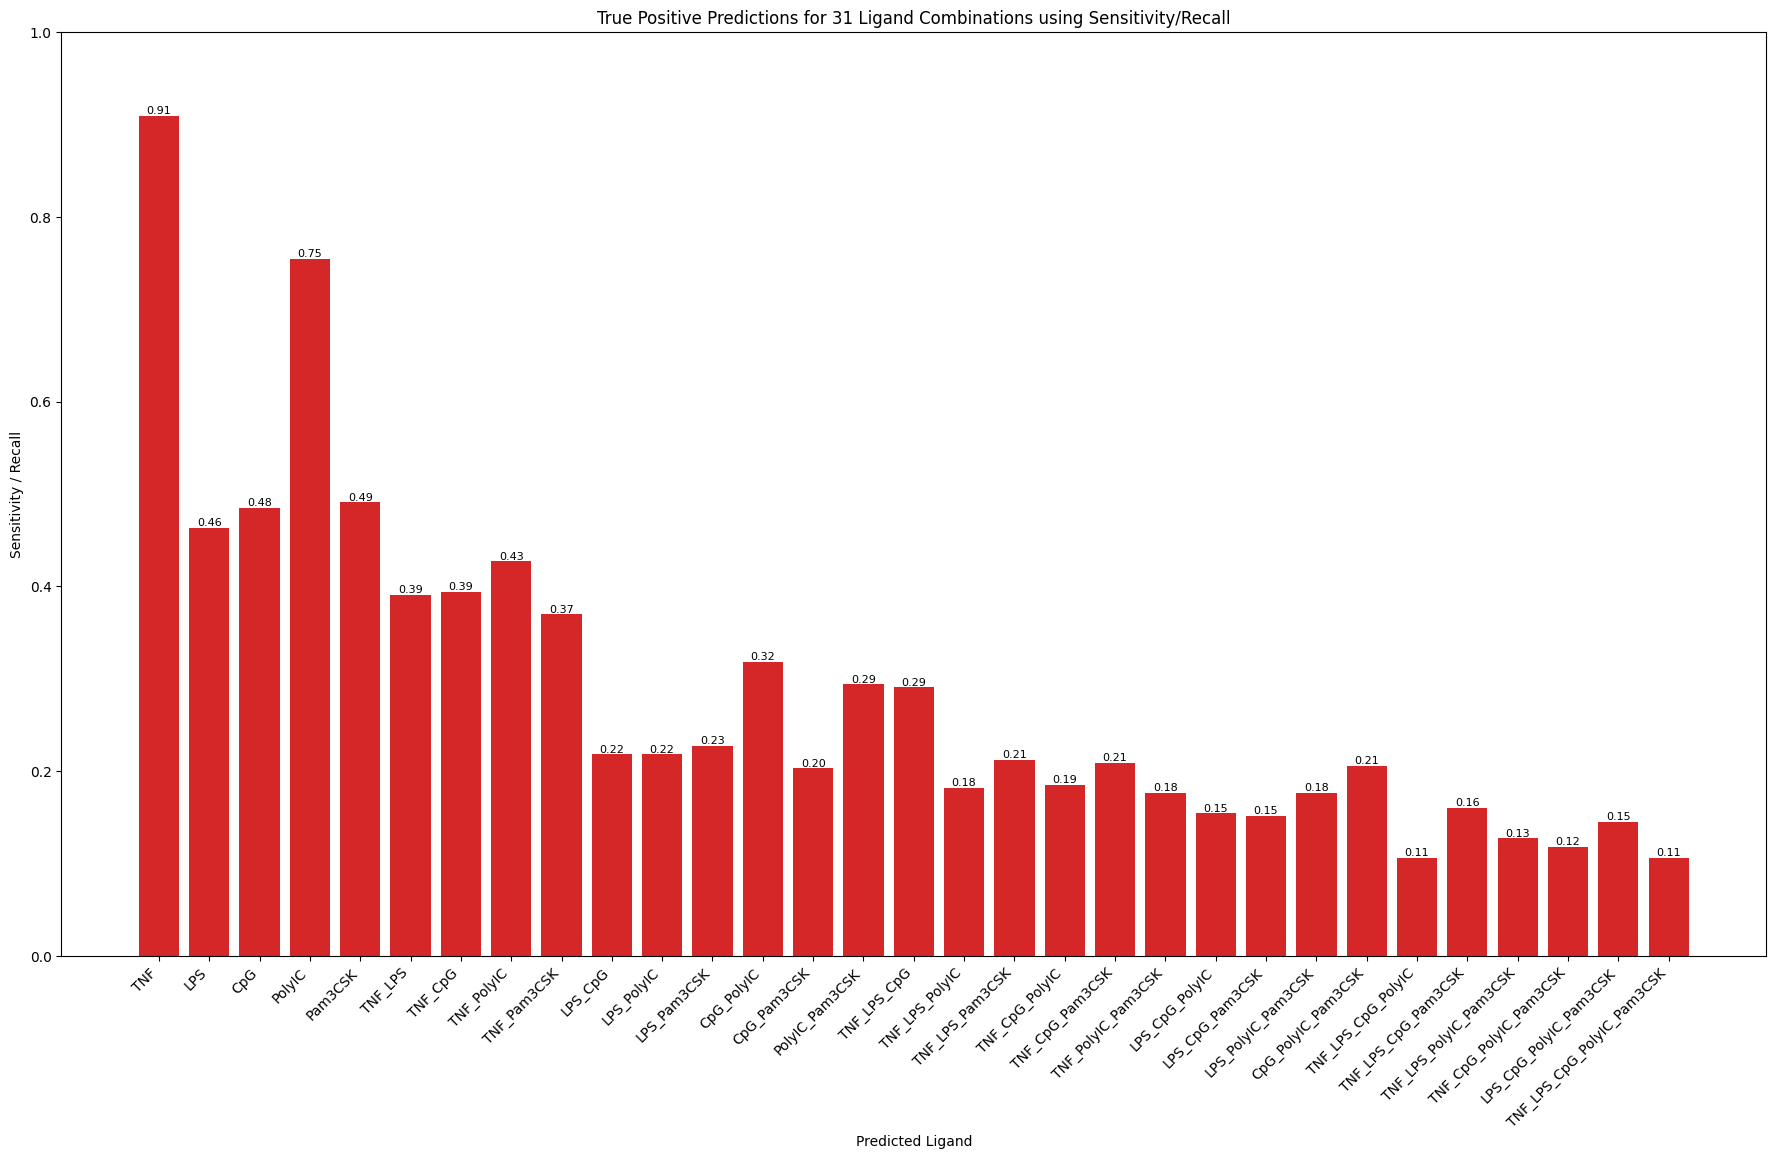

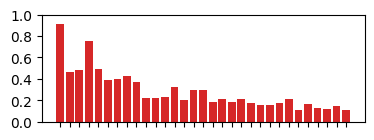

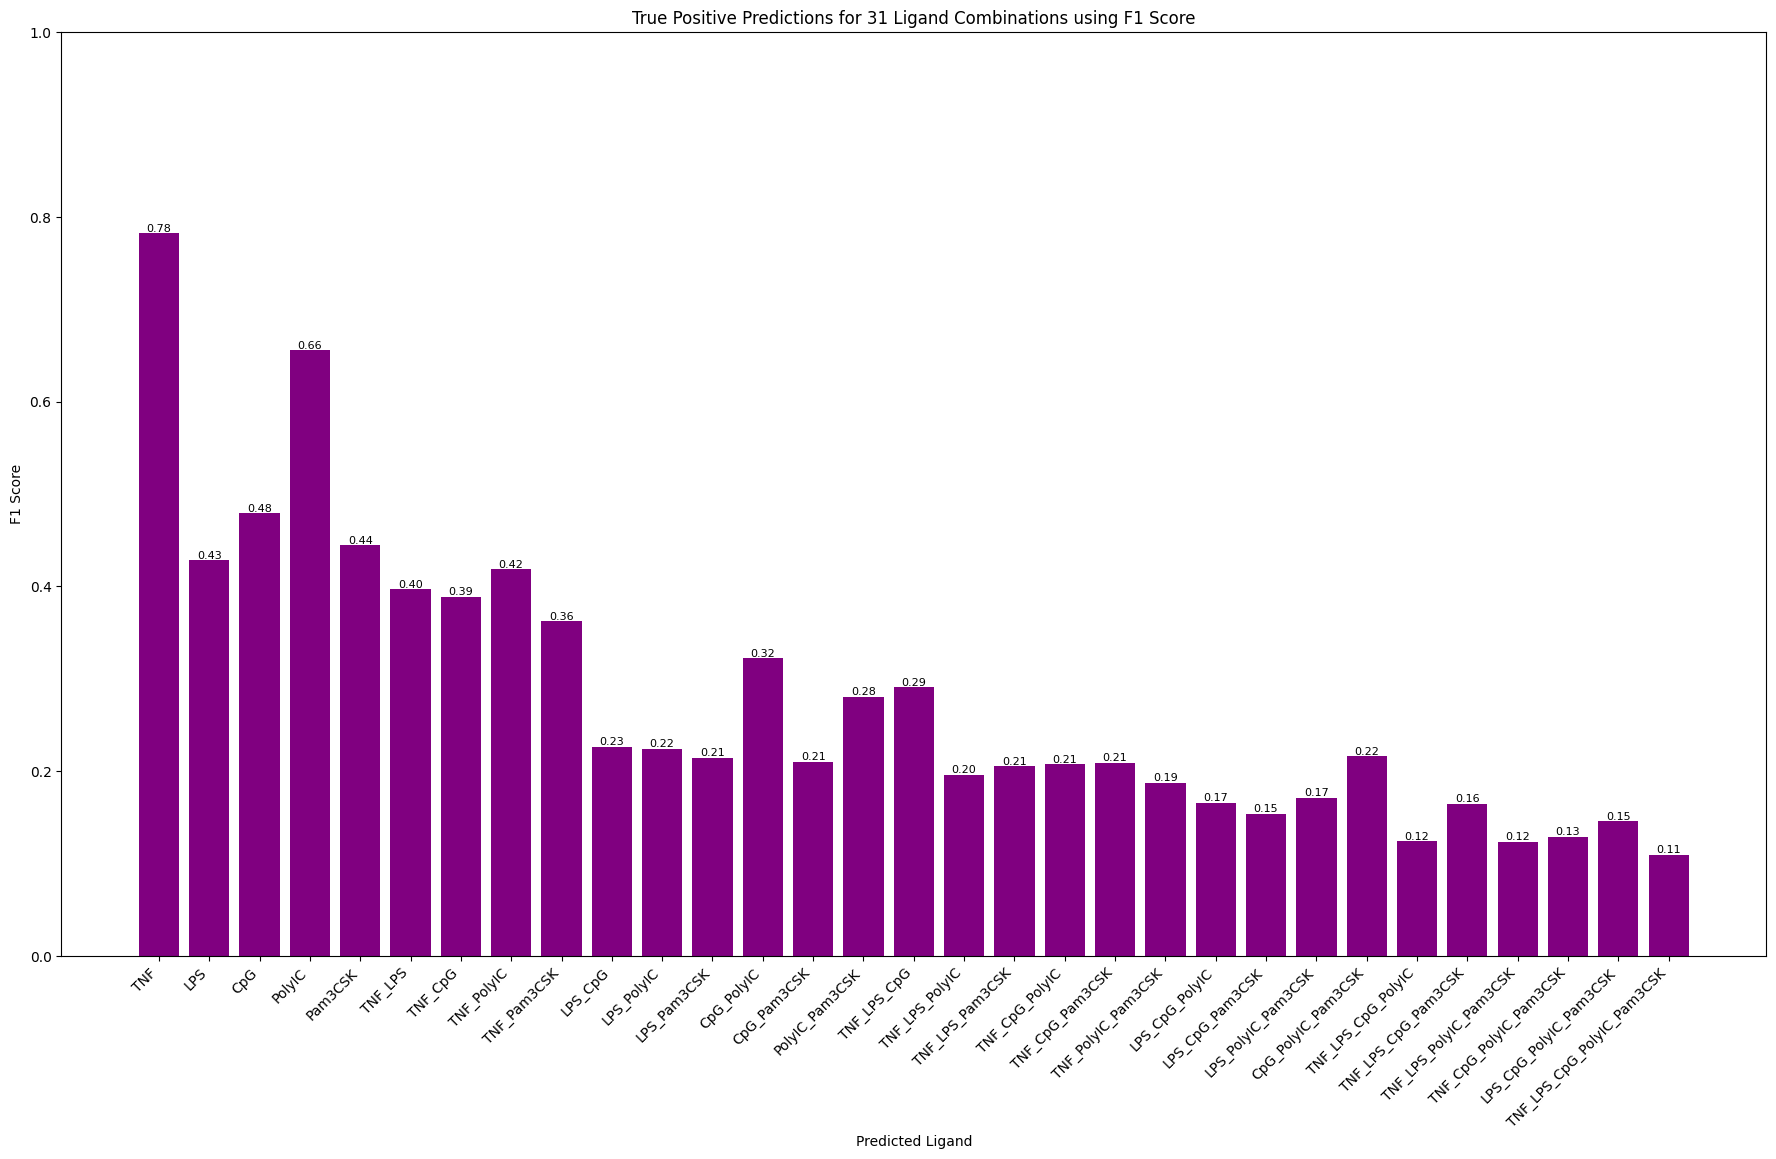

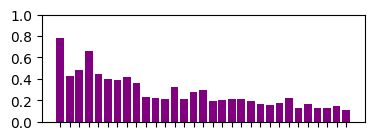

In [5]:
# Extract only the diagonal values
precision_diag = np.diag(precision)
recall_diag = np.diag(recall)

# Calculate F1 score safely
f1_score_diag = 2 * (precision_diag * recall_diag) / (precision_diag + recall_diag)

# Create NaN matrix for visualization
f1_score_diagonal = np.full_like(f1_score, np.nan)
np.fill_diagonal(f1_score_diagonal, f1_score_diag)

# Consistent colors
precision_color = "tab:blue"
recall_color = "tab:red"
f1_color = "purple"

# Set to 1 to automatically download PNGs, 0 to not download
auto_download = 0

def save_and_download(filename, download=False, formats=None):
    """Saves the current figure in specified formats and optionally downloads it."""
    if formats is None:
        formats = ['pdf']

    for fmt in formats:
        plt.savefig(f"{filename}.{fmt}", bbox_inches='tight', dpi=300)
        if download and auto_download:
            try:
                from google.colab import files
                files.download(f"{filename}.{fmt}")
            except ImportError:
                print("Not running in Colab environment. Download skipped.")


# Recall / Sensitivity Bar Plot
def plot_recall(with_labels=True):
    num_classes = len(recall_diag)

    if with_labels:
        plt.figure(figsize=(22, 12))
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts

    bars = plt.bar(
        range(num_classes),
        recall_diag,
        color=recall_color
    )

    plt.ylim(0, 1)
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

    if with_labels:
        plt.title("True Positive Predictions for 31 Ligand Combinations using Sensitivity/Recall")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Sensitivity / Recall")
        plt.xticks(
            range(num_classes),
            [label_mapping[i] for i in range(num_classes)],
            rotation=45,
            ha='right'
        )

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=8
            )

        # save_and_download("31conditions_recall_bar_plot_with_labels", download=True, formats=['pdf'])

    else:
        plt.xticks(range(num_classes))
        plt.gca().set_xticklabels([])

        save_and_download("31conditions_recall_bar_plot_without_labels", download=True, formats=['pdf'])

    plt.show()


# Precision Bar Plot
def plot_precision(with_labels=True):
    num_classes = len(precision_diag)

    if with_labels:
        plt.figure(figsize=(22, 12))
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts

    bars = plt.bar(
        range(num_classes),
        precision_diag,
        color=precision_color
    )

    plt.ylim(0, 1)
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

    if with_labels:
        plt.title("True Positive Predictions for 31 Ligand Combinations using Precision")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Precision")
        plt.xticks(
            range(num_classes),
            [label_mapping[i] for i in range(num_classes)],
            rotation=45,
            ha='right'
        )

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=8
            )

        # save_and_download("31conditions_precision_bar_plot_with_labels", download=True, formats=['pdf'])

    else:
        plt.xticks(range(num_classes))
        plt.gca().set_xticklabels([])

        save_and_download("31conditions_precision_bar_plot_without_labels", download=True, formats=['pdf'])

    plt.show()


# F1-score Bar Plot
def plot_f1_score_diag(with_labels=True):
    num_classes = len(f1_score_diag)

    if with_labels:
        plt.figure(figsize=(22, 12))
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts

    bars = plt.bar(
        range(num_classes),
        f1_score_diag,
        color=f1_color
    )

    plt.ylim(0, 1)
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

    if with_labels:
        plt.title("True Positive Predictions for 31 Ligand Combinations using F1 Score")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("F1 Score")
        plt.xticks(
            range(num_classes),
            [label_mapping[i] for i in range(num_classes)],
            rotation=45,
            ha='right'
        )

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=8
            )

        save_and_download("31conditions_f1score_bar_plot_with_labels", download=True, formats=['pdf'])

    else:
        plt.xticks(range(num_classes))
        plt.gca().set_xticklabels([])

        save_and_download("31conditions_f1score_bar_plot_without_labels", download=True, formats=['pdf'])

    plt.show()


# Generate all versions of the plots
plot_precision(with_labels=True)
plot_precision(with_labels=False)

plot_recall(with_labels=True)
plot_recall(with_labels=False)

plot_f1_score_diag(with_labels=True)
plot_f1_score_diag(with_labels=False)

In [6]:
import numpy as np
import pandas as pd

precision_diag = np.diag(precision)
sensitivity_diag = np.diag(recall)

f1_score_diag = np.divide(
    2 * precision_diag * sensitivity_diag,
    precision_diag + sensitivity_diag,
    out=np.full_like(precision_diag, np.nan, dtype=float),
    where=(precision_diag + sensitivity_diag) != 0
)

num_classes = len(precision_diag)

condition_indices = list(range(num_classes))

condition_labels = [
    label_mapping[i] if i in label_mapping else f"Condition_{i}"
    for i in condition_indices
]

sensitivity_df = pd.DataFrame({
    "Condition_index": condition_indices,
    "Condition_label": condition_labels,
    "Sensitivity/Recall": sensitivity_diag
})

precision_df = pd.DataFrame({
    "Condition_index": condition_indices,
    "Condition_label": condition_labels,
    "Precision": precision_diag
})

f1_df = pd.DataFrame({
    "Condition_index": condition_indices,
    "Condition_label": condition_labels,
    "F1_score": f1_score_diag
})

description_df = pd.DataFrame({
    "Source data description": [""]
})

output_file = "31conditions_sensitivity_precision_f1_source_data.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    description_df.to_excel(writer, sheet_name="Data description", index=False)
    sensitivity_df.to_excel(writer, sheet_name="Sensitivity", index=False)
    precision_df.to_excel(writer, sheet_name="Precision", index=False)
    f1_df.to_excel(writer, sheet_name="F1 score", index=False)

print(f"Saved source data to: {output_file}")

from google.colab import files
files.download(output_file)


Saved source data to: 31conditions_sensitivity_precision_f1_source_data.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ValueError: No Excel writer 'xlwt'


# Fig S3C Heatmaps


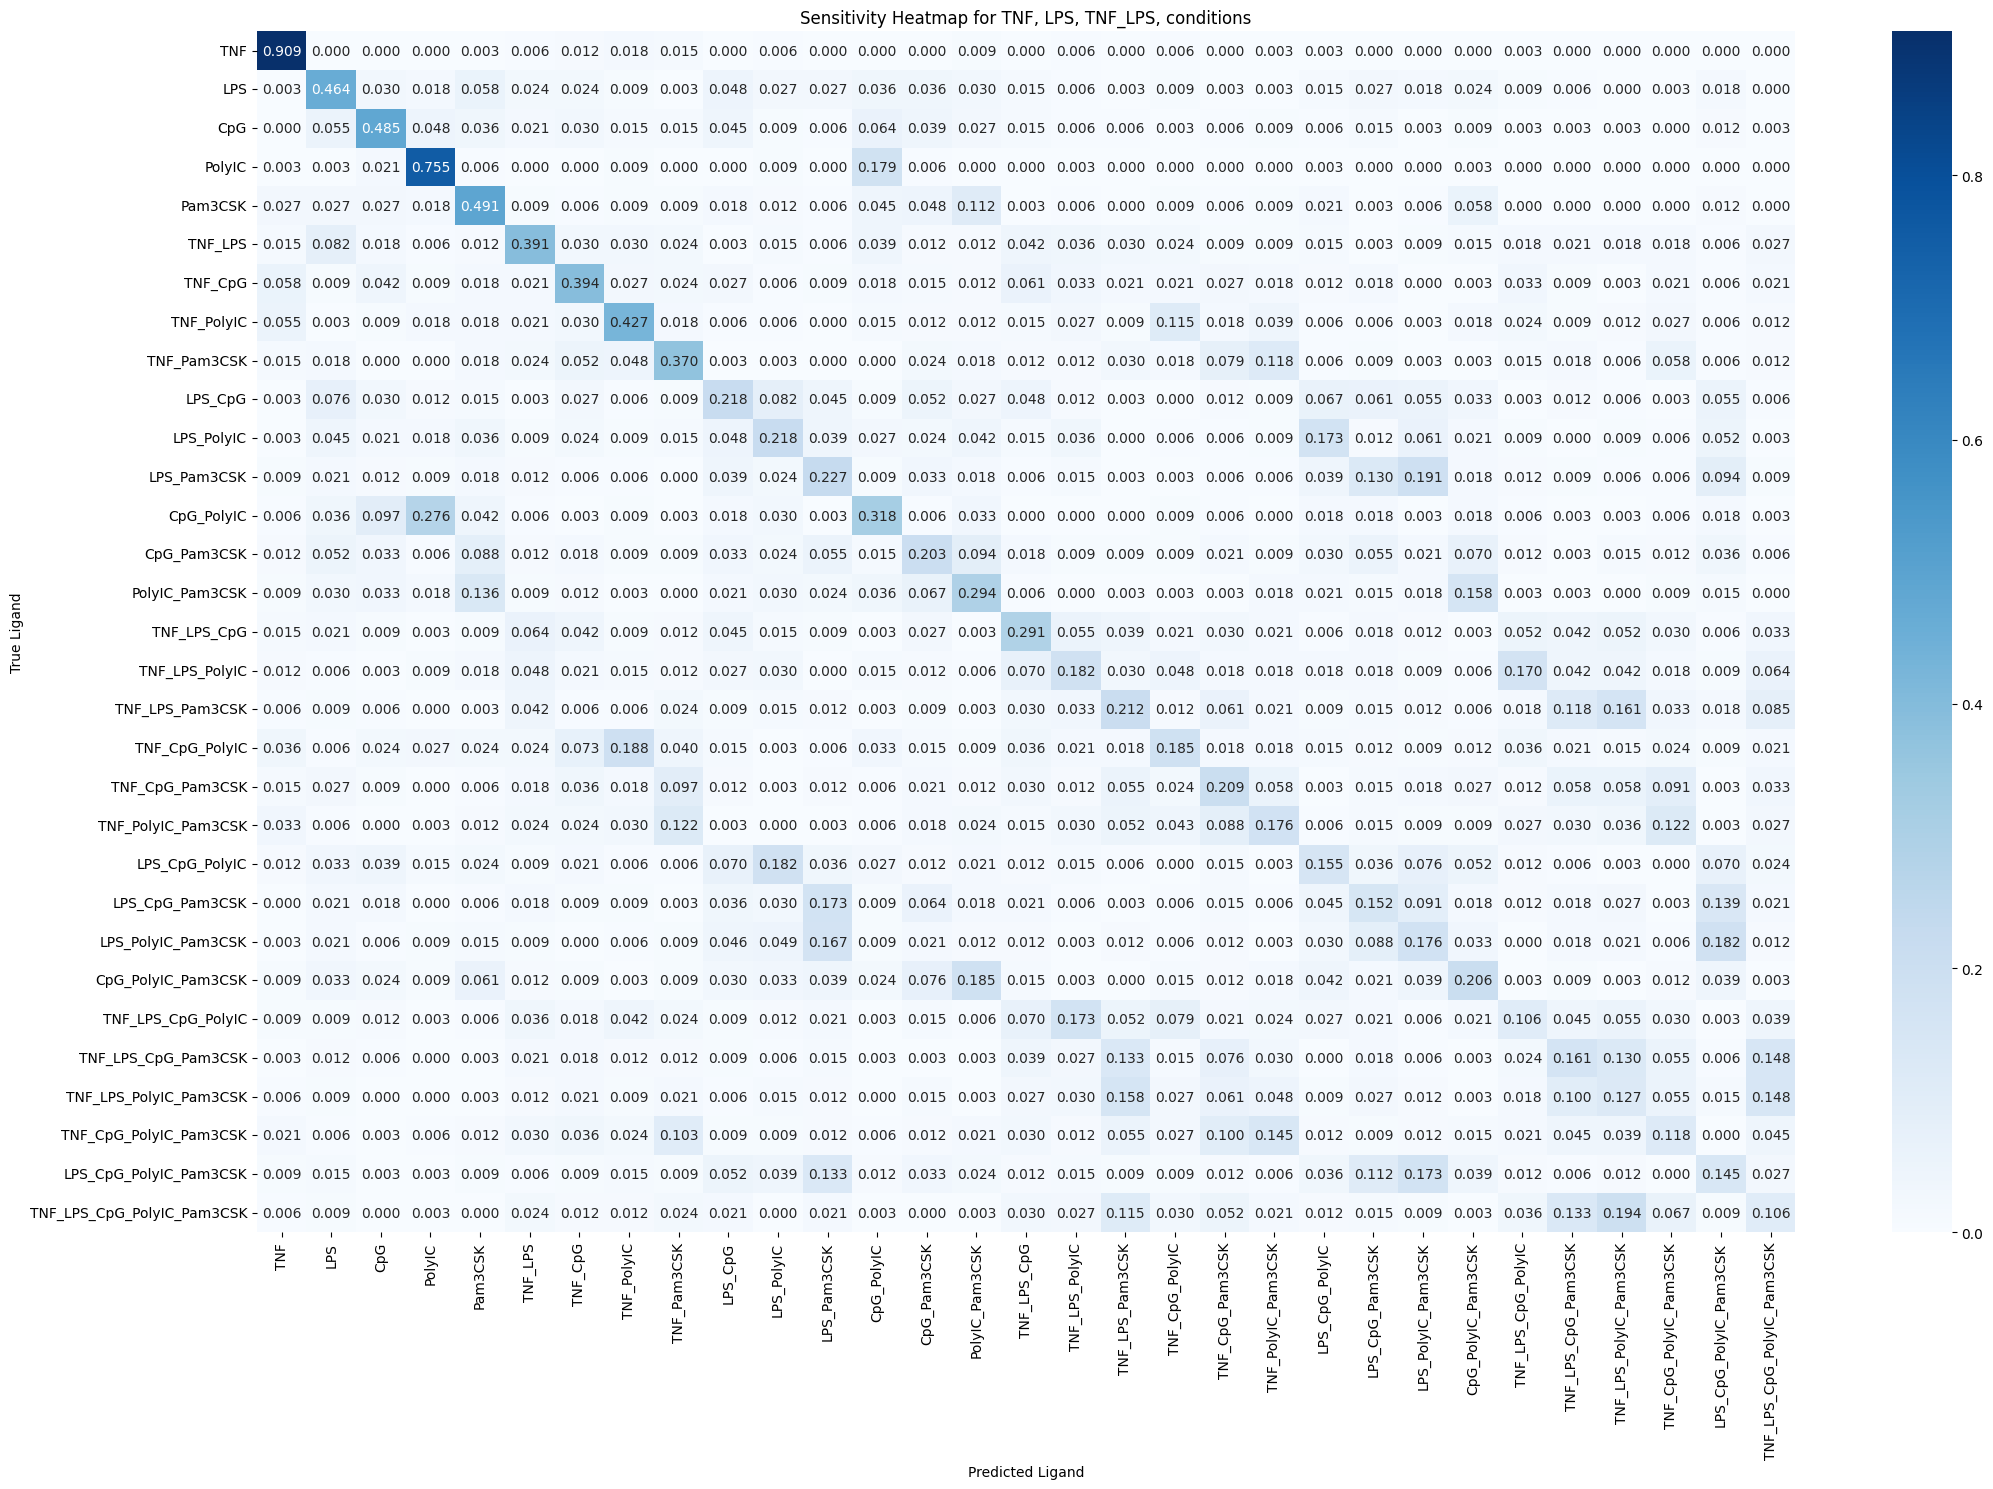

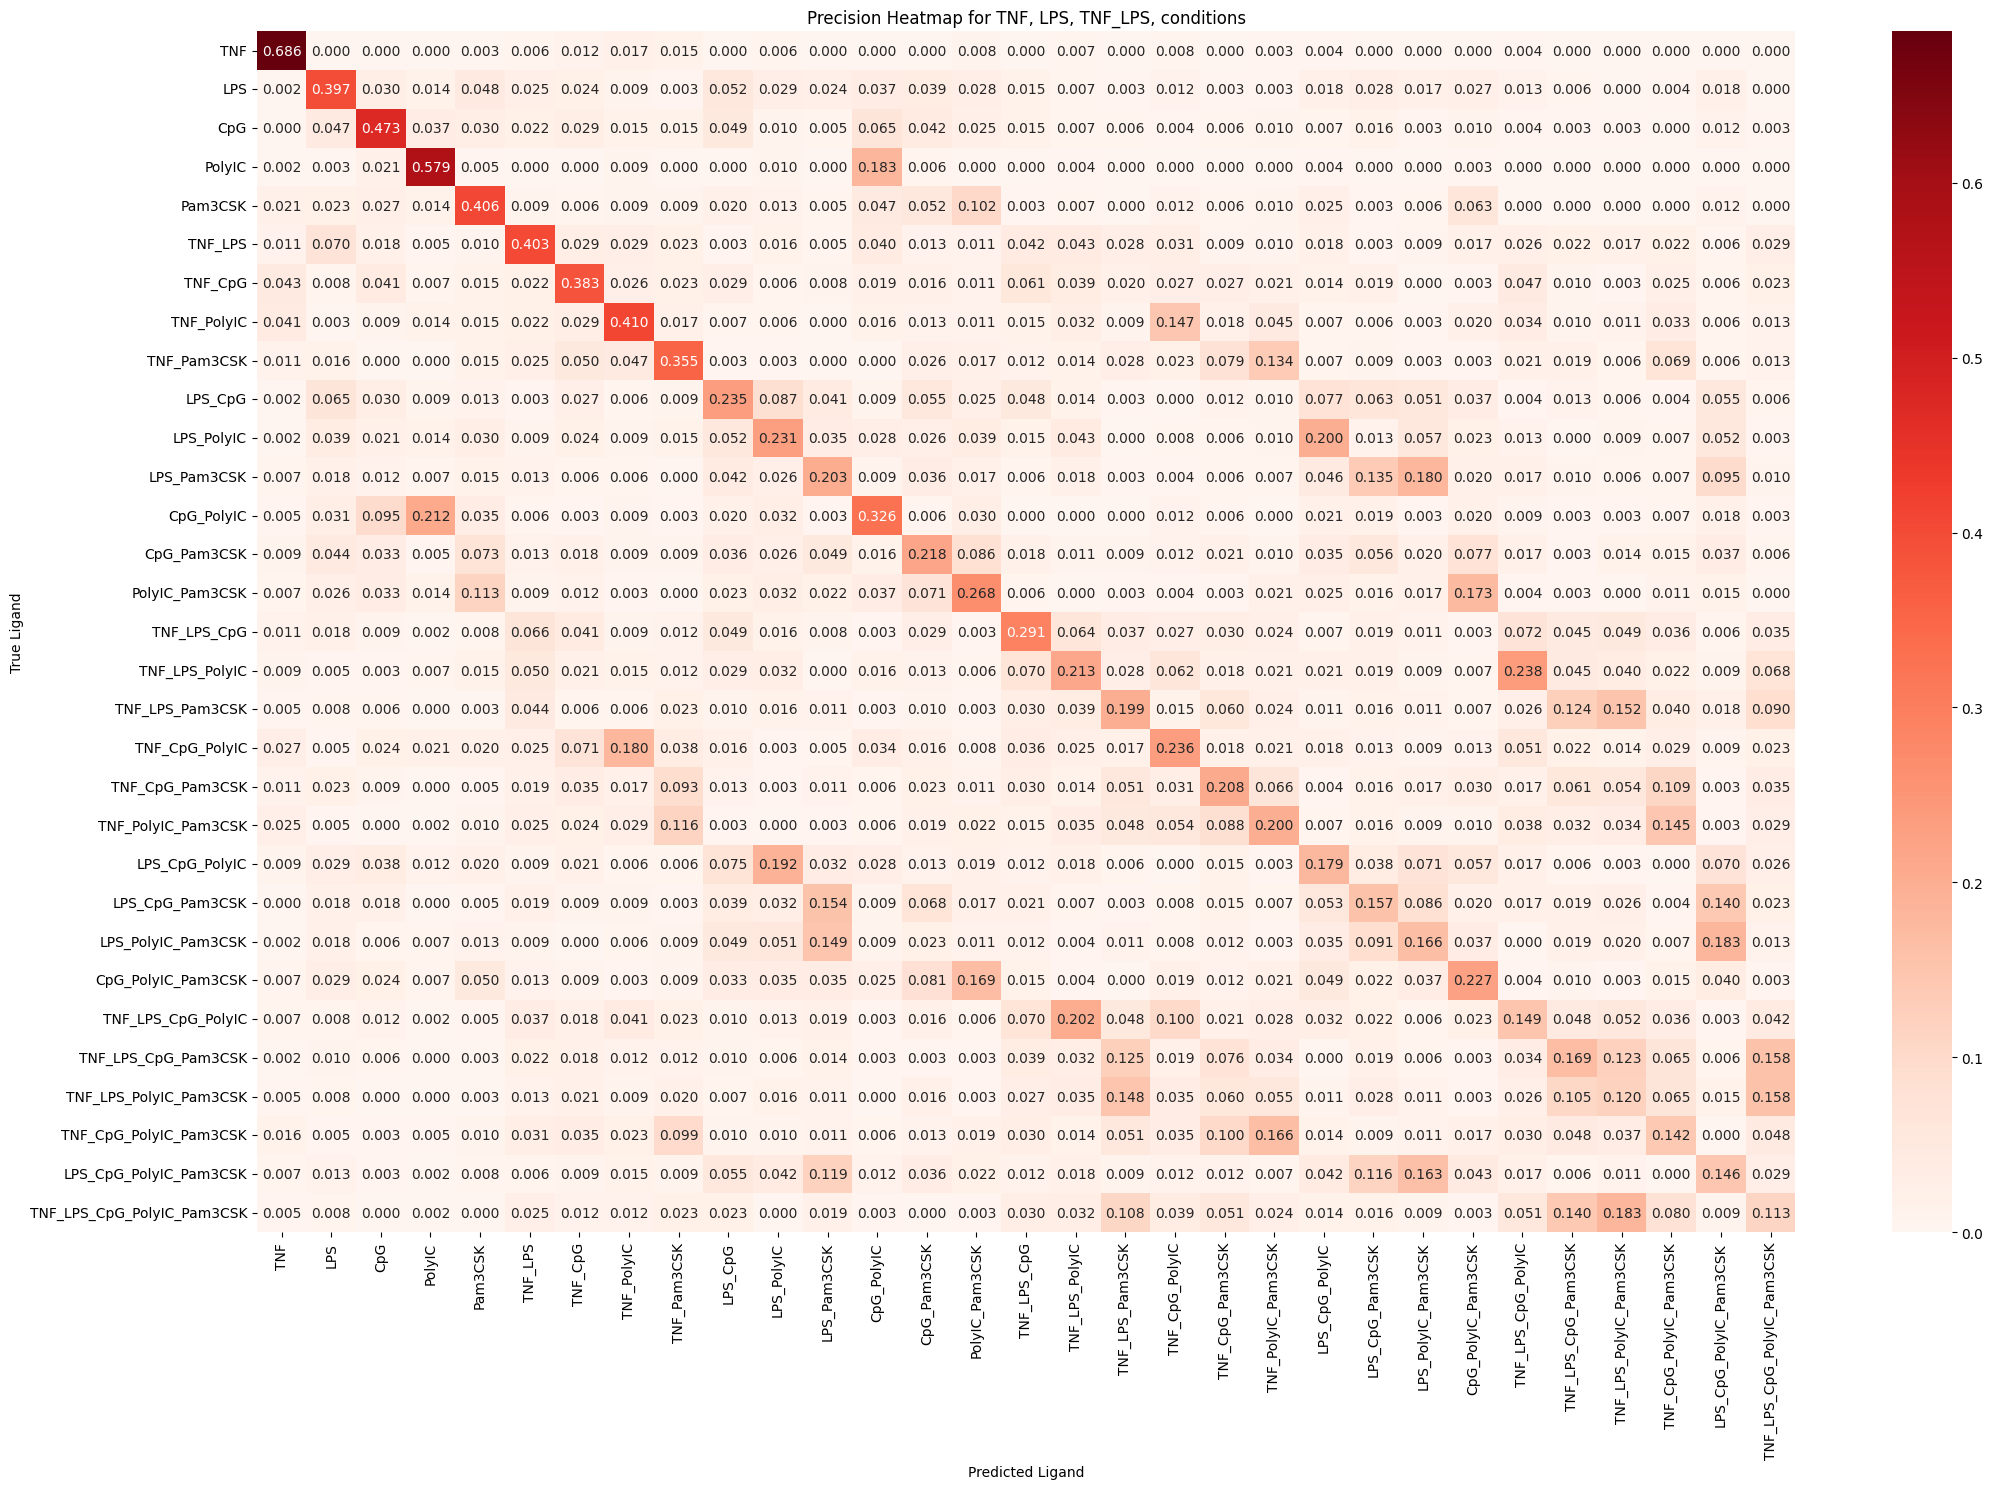

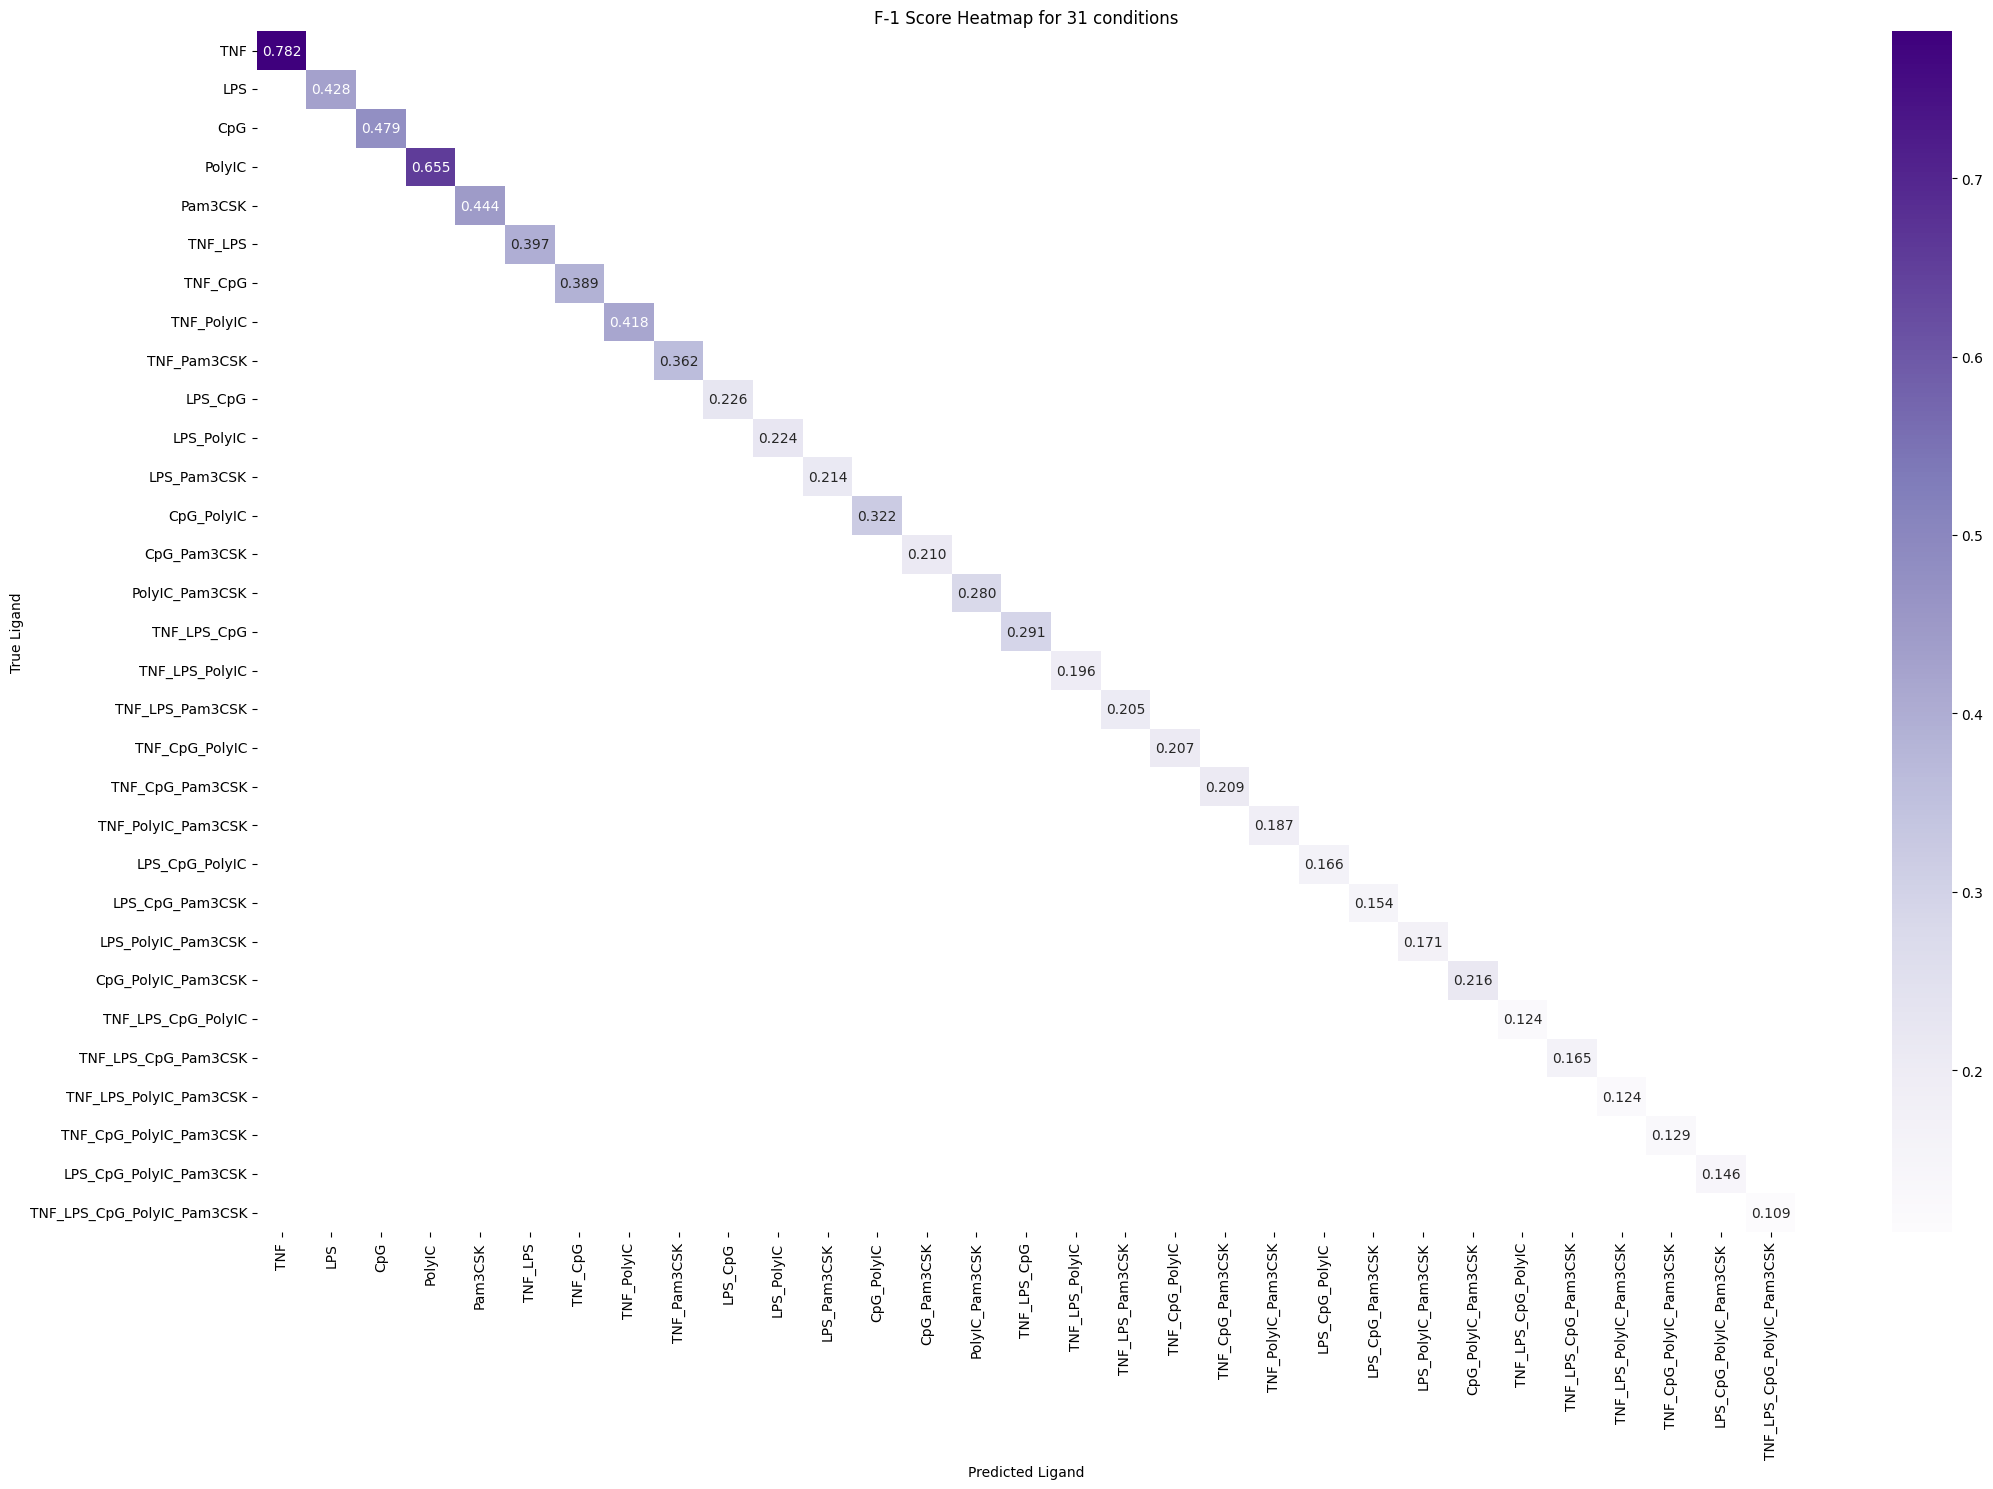

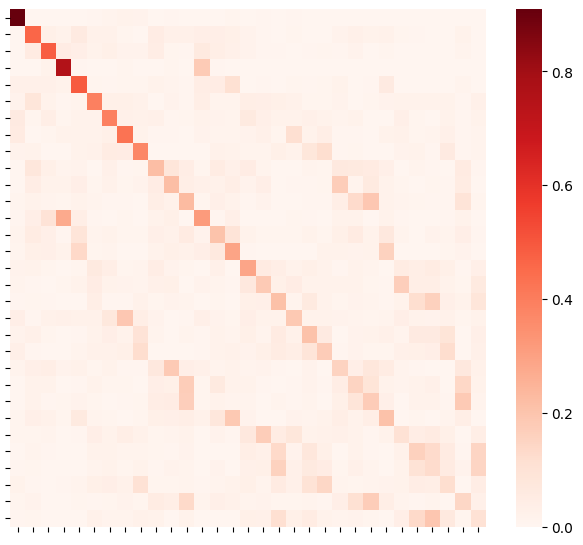

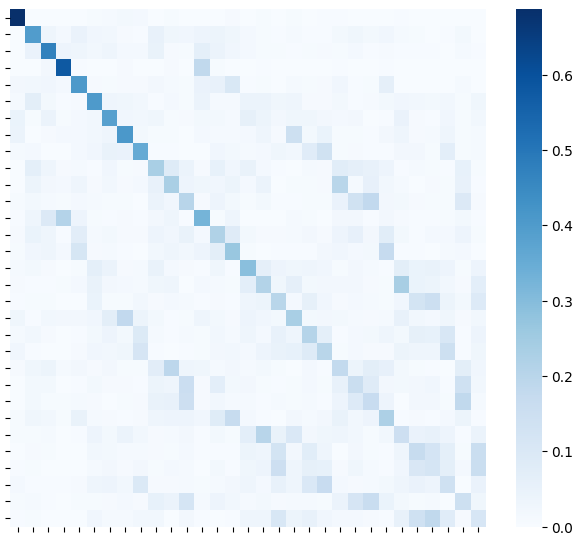

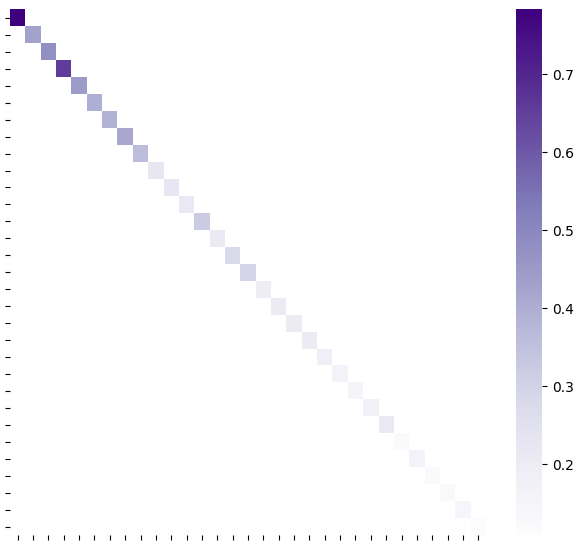

In [7]:
# Plot sensitivity heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(recall, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[label_mapping[i] for i in range(31)],
            yticklabels=[label_mapping[i] for i in range(31)])
plt.title('Sensitivity Heatmap for TNF, LPS, TNF_LPS, conditions')
plt.xlabel('Predicted Ligand')
plt.ylabel('True Ligand')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
#save_and_download("31conditions_sensitivity_heatmap", download=True, formats=['pdf'])
plt.show()

# Plot precision heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(precision, annot=True, fmt='.3f', cmap='Reds',
            xticklabels=[label_mapping[i] for i in range(31)],
            yticklabels=[label_mapping[i] for i in range(31)])
plt.title('Precision Heatmap for TNF, LPS, TNF_LPS, conditions')
plt.xlabel('Predicted Ligand')
plt.ylabel('True Ligand')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
#save_and_download("31conditions_precision_heatmap", download=True, formats=['pdf'])
plt.show()

# Plot F-1 DIAG score heatmap
plt.figure(figsize=(22,15))
sns.heatmap(f1_score_diagonal, annot=True, fmt='.3f', cmap='Purples',
            xticklabels=[label_mapping[i] for i in range(31)],
            yticklabels=[label_mapping[i] for i in range(31)])
plt.title('F-1 Score Heatmap for 31 conditions')
plt.xlabel('Predicted Ligand')
plt.ylabel('True Ligand')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
#save_and_download("31conditions_f1_score_heatmap", download=True, formats=['pdf'])
plt.show()

# Unlabeled sensitivity heatmap
plt.figure(figsize=(450/72, 400/72))
sns.heatmap(recall, annot=False, cmap='Reds', xticklabels=False, yticklabels=False)
plt.xticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping], rotation=90)
plt.yticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping])
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()
save_and_download("31conditions_sensitivity_heatmap_unlabeled", download=True, formats=['pdf'])
plt.show()

# Unlabeled precision heatmap
plt.figure(figsize=(450/72, 400/72))
sns.heatmap(precision, annot=False, cmap='Blues', xticklabels=False, yticklabels=False)
plt.xticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping], rotation=90)
plt.yticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping])
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()
save_and_download("31conditions_precision_heatmap_unlabeled", download=True, formats=['pdf'])
plt.show()

# Unlabeled z-1 DIAG score heatmap
plt.figure(figsize=(450/72, 400/72))
sns.heatmap(f1_score_diagonal, annot=False, cmap='Purples', xticklabels=False, yticklabels=False)
plt.xticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping], rotation=90)
plt.yticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping])
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()
save_and_download("31conditions_f1_score_heatmap_unlabeled", download=True, formats=['pdf'])
plt.show()